# CodeAlpha Task 3 — Car Price Prediction with Machine Learning

Predict a used car's selling price from features like brand, age, mileage (present price, kms driven), fuel type, and transmission.

Two regression approaches are compared:
1. `RandomForestRegressor` (scikit-learn baseline)
2. A small feed-forward neural network trained on the GPU (PyTorch + CUDA)

Dataset: `data/car data.csv` (Kaggle: vijayaadithyanvg/car-price-predictionused-cars)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style="whitegrid")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 3060


## 1. Load and explore the data

In [2]:
df = pd.read_csv("data/car data.csv")
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
print(df.shape)
print(df.isna().sum())
df.describe(include="all")

(301, 9)
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
count,301,301.000000,301.000000,301.000000,301.000000,301,301,301,301.000000
unique,98,NaN,NaN,NaN,NaN,3,2,2,NaN
top,city,NaN,NaN,NaN,NaN,Petrol,Dealer,Manual,NaN
freq,26,NaN,NaN,NaN,NaN,239,195,261,NaN
mean,NaN,2013.627907,4.661296,7.628472,36947.205980,NaN,NaN,NaN,0.043189
std,NaN,2.891554,5.082812,8.642584,38886.883882,NaN,NaN,NaN,0.247915
min,NaN,2003.000000,0.100000,0.320000,500.000000,NaN,NaN,NaN,0.000000
25%,NaN,2012.000000,0.900000,1.200000,15000.000000,NaN,NaN,NaN,0.000000
50%,NaN,2014.000000,3.600000,6.400000,32000.000000,NaN,NaN,NaN,0.000000
75%,NaN,2016.000000,6.000000,9.900000,48767.000000,NaN,NaN,NaN,0.000000


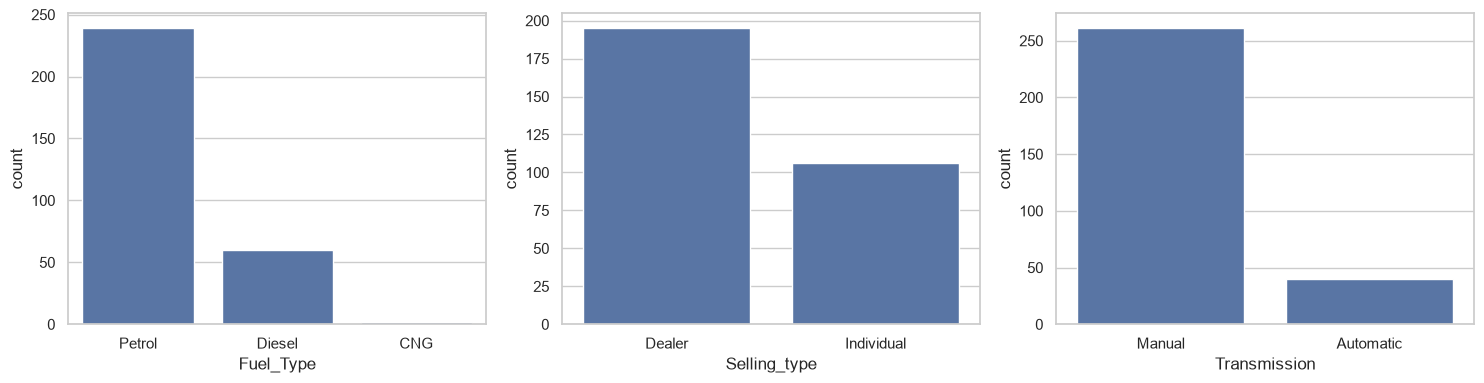

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(data=df, x="Fuel_Type", ax=axes[0])
sns.countplot(data=df, x="Selling_type", ax=axes[1])
sns.countplot(data=df, x="Transmission", ax=axes[2])
plt.tight_layout()
plt.show()

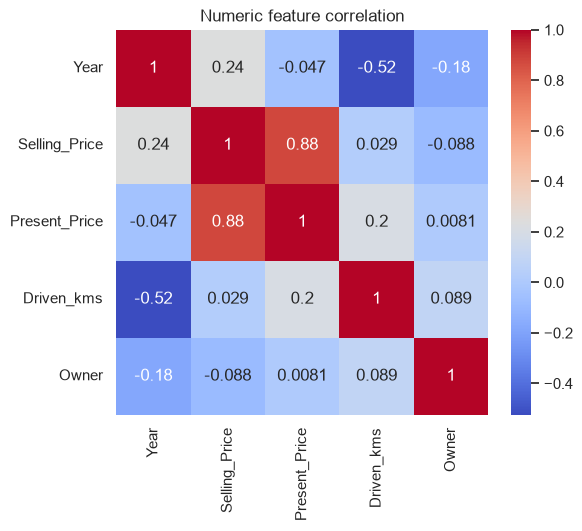

In [5]:
plt.figure(figsize=(6, 5))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm")
plt.title("Numeric feature correlation")
plt.show()

## 2. Feature engineering

- Convert `Year` into `Car_Age` (dataset is from 2020, so `Car_Age = 2020 - Year`).
- Drop `Car_Name` (too high-cardinality to be useful directly; brand goodwill is already reflected in `Present_Price`).
- One-hot encode categorical columns: `Fuel_Type`, `Selling_type`, `Transmission`.

In [6]:
data = df.copy()
data["Car_Age"] = 2020 - data["Year"]
data = data.drop(columns=["Car_Name", "Year"])

data = pd.get_dummies(data, columns=["Fuel_Type", "Selling_type", "Transmission"], drop_first=True)
data.head()

,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,6,False,True,False,True
1,4.75,9.54,43000,0,7,True,False,False,True
2,7.25,9.85,6900,0,3,False,True,False,True
3,2.85,4.15,5200,0,9,False,True,False,True
4,4.60,6.87,42450,0,6,True,False,False,True


In [7]:
X = data.drop(columns=["Selling_Price"]).astype(float).values
y = data["Selling_Price"].values
feature_names = data.drop(columns=["Selling_Price"]).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

x_scaler = StandardScaler()
X_train_s = x_scaler.fit_transform(X_train)
X_test_s = x_scaler.transform(X_test)

y_scaler = StandardScaler()
y_train_s = y_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test_s = y_scaler.transform(y_test.reshape(-1, 1)).ravel()

print(X_train_s.shape, X_test_s.shape)

(240, 8) (61, 8)


## 3. Baseline: RandomForestRegressor (scikit-learn, CPU)

In [8]:
rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_train_s, y_train)
rf_pred = rf.predict(X_test_s)

rf_rmse = mean_squared_error(y_test, rf_pred) ** 0.5
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)
print(f"RandomForest -> RMSE: {rf_rmse:.4f} | MAE: {rf_mae:.4f} | R2: {rf_r2:.4f}")

RandomForest -> RMSE: 0.9441 | MAE: 0.6221 | R2: 0.9613


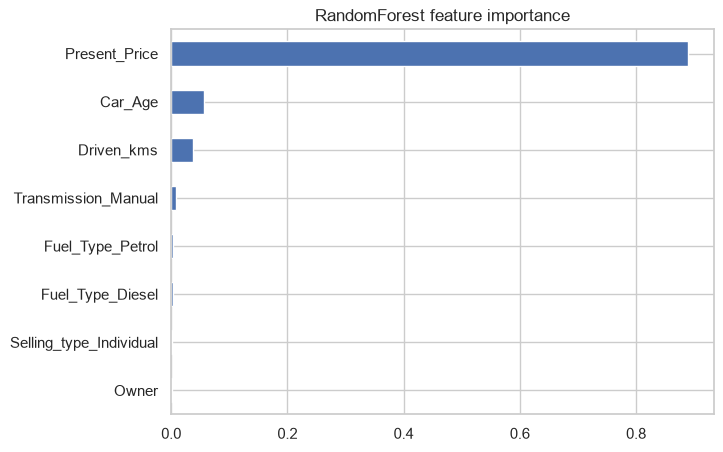

In [9]:
importances = pd.Series(rf.feature_importances_, index=feature_names).sort_values()
importances.plot(kind="barh", figsize=(7, 5), title="RandomForest feature importance")
plt.show()

## 4. Neural network regressor trained on GPU (PyTorch)

In [10]:
X_train_t = torch.tensor(X_train_s, dtype=torch.float32, device=device)
y_train_t = torch.tensor(y_train_s, dtype=torch.float32, device=device).view(-1, 1)
X_test_t = torch.tensor(X_test_s, dtype=torch.float32, device=device)
y_test_t = torch.tensor(y_test_s, dtype=torch.float32, device=device).view(-1, 1)

class CarPriceNet(nn.Module):
    def __init__(self, in_features, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Linear(hidden // 2, 1),
        )

    def forward(self, x):
        return self.net(x)

model = CarPriceNet(in_features=X_train_s.shape[1]).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)
print(model)

CarPriceNet(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [11]:
epochs = 800
history = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    out = model(X_train_t)
    loss = criterion(out, y_train_t)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        test_loss = criterion(model(X_test_t), y_test_t)
    history.append((loss.item(), test_loss.item()))

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1:4d} | train_loss {loss.item():.5f} | test_loss {test_loss.item():.5f}")

Epoch  100 | train_loss 0.00809 | test_loss 0.01288


Epoch  200 | train_loss 0.00634 | test_loss 0.01190
Epoch  300 | train_loss 0.00493 | test_loss 0.01276


Epoch  400 | train_loss 0.00419 | test_loss 0.01453
Epoch  500 | train_loss 0.00352 | test_loss 0.01630


Epoch  600 | train_loss 0.00421 | test_loss 0.02081
Epoch  700 | train_loss 0.00355 | test_loss 0.02033


Epoch  800 | train_loss 0.00243 | test_loss 0.01977


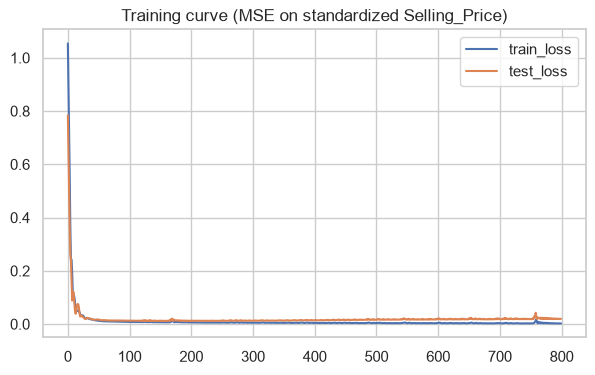

In [12]:
hist_df = pd.DataFrame(history, columns=["train_loss", "test_loss"])
hist_df.plot(figsize=(7, 4), title="Training curve (MSE on standardized Selling_Price)")
plt.show()

In [13]:
model.eval()
with torch.no_grad():
    nn_pred_s = model(X_test_t).cpu().numpy()
nn_pred = y_scaler.inverse_transform(nn_pred_s).ravel()

nn_rmse = mean_squared_error(y_test, nn_pred) ** 0.5
nn_mae = mean_absolute_error(y_test, nn_pred)
nn_r2 = r2_score(y_test, nn_pred)
print(f"PyTorch NN -> RMSE: {nn_rmse:.4f} | MAE: {nn_mae:.4f} | R2: {nn_r2:.4f}")

PyTorch NN -> RMSE: 0.7229 | MAE: 0.4642 | R2: 0.9773


## 5. Predicted vs actual & final comparison

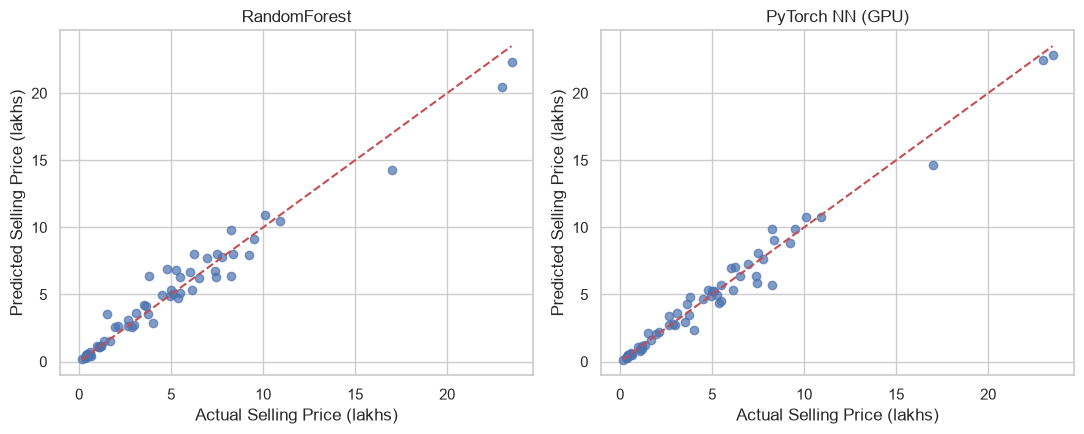

Model                   RMSE     MAE      R2
RandomForest           0.944   0.622   0.961
PyTorch NN (GPU)       0.723   0.464   0.977


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, pred, title in zip(axes, [rf_pred, nn_pred], ["RandomForest", "PyTorch NN (GPU)"]):
    ax.scatter(y_test, pred, alpha=0.7)
    lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    ax.plot(lims, lims, "r--")
    ax.set_xlabel("Actual Selling Price (lakhs)")
    ax.set_ylabel("Predicted Selling Price (lakhs)")
    ax.set_title(title)
plt.tight_layout()
plt.show()

print(f"{'Model':<20}{'RMSE':>8}{'MAE':>8}{'R2':>8}")
print(f"{'RandomForest':<20}{rf_rmse:>8.3f}{rf_mae:>8.3f}{rf_r2:>8.3f}")
print(f"{'PyTorch NN (GPU)':<20}{nn_rmse:>8.3f}{nn_mae:>8.3f}{nn_r2:>8.3f}")

## 6. Insight

`Present_Price` (a proxy for brand goodwill / original MSRP) dominates predictive power, followed by `Car_Age` and `Driven_kms` — consistent with real-world used-car depreciation: newer, less-driven, higher-MSRP cars command higher resale prices.